# 04. Baseline Machine Learning Models

## 1. Objective

The objective of this notebook is to establish baseline machine-learning models for binary heart disease classification using the Cleveland subset of the UCI Heart Disease dataset.

The models are trained using the preprocessing workflow established during exploratory data analysis and preprocessing. Six classification algorithms are evaluated using stratified cross-validation on the training data. Model performance is assessed using accuracy, precision, recall (sensitivity), specificity, F1-score, and ROC-AUC rather than accuracy alone.

The preprocessing transformations are incorporated into model pipelines so that imputation, scaling, and categorical encoding are learned only from the corresponding training folds during cross-validation. This prevents data leakage.

The final test set, which contains 61 observations, remains untouched during model development and cross-validation. It is used only after the baseline models have been selected for final baseline evaluation.

The baseline results provide a reference point for subsequent feature-selection, advanced-model, and ensemble experiments and for comparison with relevant literature.


## 2. Imports and Configuration

The required Python libraries are imported for data handling, preprocessing, model construction, cross-validation, performance evaluation, and visualization.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
)

RANDOM_STATE = 42


## 3. Load Dataset

The Cleveland heart disease dataset is loaded using the same data source and target definition established in the previous notebooks.

The original `num` variable is converted into a binary target:

- `0`: no presence of heart disease
- `1`: presence of heart disease

The same predictor variables used during EDA and preprocessing are retained.


In [2]:
DATA_PATH = Path("../data/raw/processed.cleveland.data")

print("Dataset path:", DATA_PATH.resolve())
print("Dataset exists:", DATA_PATH.exists())

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]

df = pd.read_csv(
    DATA_PATH,
    names=columns,
    na_values="?"
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset path: ../data/raw/processed.cleveland.data
Dataset exists: True
Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 4. Define Predictors and Target

The model development uses the 13 predictor variables identified during dataset validation and EDA. The binary `target` variable is used as the classification outcome.

In [3]:
df["target"] = (df["num"] > 0).astype(int)

predictor_features = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal"
]

X = df[predictor_features].copy()
y = df["target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(y.value_counts())

assert set(df["num"].dropna().unique()) <= {0, 1, 2, 3, 4}
assert len(predictor_features) == 13
assert "num" not in predictor_features

assert df.shape == (303, 15)  # 14 source columns plus derived binary target


X shape: (303, 13)
y shape: (303,)


target
0    164
1    139
Name: count, dtype: int64

## 5. Train/Test Split

The dataset is divided into training and testing subsets using an 80:20 stratified split with `random_state = 42`.

The split established during the previous preprocessing stage is reproduced here to maintain consistency across notebooks.

The training set is used for cross-validation and model development. The test set remains untouched until final baseline evaluation.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())
print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())


X_train: (242, 13)
X_test : (61, 13)
y_train: (242,)
y_test : (61,)

Training target distribution:
target
0    131
1    111
Name: count, dtype: int64

Testing target distribution:
target
0    33
1    28
Name: count, dtype: int64


## 6. Feature Types

The predictor variables are divided into numerical and categorical features according to the preprocessing decisions established during EDA.

The `ca` and `thal` variables are treated as categorical variables because their values represent discrete clinical categories rather than continuous measurements.

In [5]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]


## 7. Preprocessing Pipeline

The preprocessing strategy developed during EDA is integrated directly into the machine-learning pipeline.

Numerical variables are processed using median imputation followed by standardization.

Categorical variables are processed using most-frequent imputation followed by one-hot encoding.

The transformer is not fitted separately on the complete dataset. Instead, it is included inside each model pipeline so that preprocessing is learned only from the training portion of each cross-validation fold.


In [6]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 8. Baseline Models

Six standard supervised classifiers are used to establish the baseline: Logistic Regression, K-Nearest Neighbors, Decision Tree, Gaussian Naive Bayes, Support Vector Machine, and Random Forest. This set provides linear, distance-based, probabilistic, tree-based, kernel-based, and ensemble perspectives while remaining consistent with the project methodology and literature review.

No extensive hyperparameter optimization is performed in this notebook. The purpose is to establish reproducible baseline performance before any later model tuning, feature selection, or advanced ensemble experiments.


In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Support Vector Machine": SVC(
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    )
}


## 9. Create Model Pipelines

In [8]:
model_pipelines = {}

for model_name, model in models.items():

    model_pipelines[model_name] = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model)
        ]
    )

# Check model names
print(model_pipelines.keys())

for model_name, pipeline in model_pipelines.items():
    print(model_name, "->", pipeline.named_steps.keys())

dict_keys(['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'Gaussian Naive Bayes', 'Support Vector Machine', 'Random Forest'])
Logistic Regression -> dict_keys(['preprocessor', 'model'])
K-Nearest Neighbors -> dict_keys(['preprocessor', 'model'])
Decision Tree -> dict_keys(['preprocessor', 'model'])
Gaussian Naive Bayes -> dict_keys(['preprocessor', 'model'])
Support Vector Machine -> dict_keys(['preprocessor', 'model'])
Random Forest -> dict_keys(['preprocessor', 'model'])


## 10. Cross-Validation Strategy

Stratified 5-fold cross-validation is used on the training set.

Stratification ensures that each fold maintains approximately the same distribution of the binary target variable.

The test set is not involved in cross-validation.

A fixed random state is used to make the cross-validation procedure reproducible.

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

## 11. Evaluation Metrics

Model performance is evaluated using multiple metrics.

Accuracy measures the overall proportion of correctly classified observations.

Precision measures the proportion of predicted positive cases that are actually positive.

Recall, also referred to as sensitivity, measures the proportion of actual positive cases correctly identified by the model.

Specificity measures the proportion of actual negative cases correctly identified.

F1-score is the harmonic mean of precision and recall.

ROC-AUC measures the model's ability to distinguish between the two target classes across classification thresholds.

Because this is a medical classification problem, recall and specificity are reported alongside accuracy rather than relying on accuracy alone.


## 12. Cross-Validation Baseline Evaluation

In [10]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "specificity": make_scorer(recall_score, pos_label=0),
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name, pipeline in model_pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        error_score="raise",
        return_train_score=False
    )

    result = {"Model": model_name}
    for metric in scoring:
        result[f"{metric}_Mean"] = scores[f"test_{metric}"].mean()
        result[f"{metric}_SD"] = scores[f"test_{metric}"].std(ddof=0)
    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.sort_values("roc_auc_Mean", ascending=False).round(4)
)


,Model,accuracy_Mean,accuracy_SD,precision_Mean,precision_SD,recall_Mean,recall_SD,specificity_Mean,specificity_SD,f1_Mean,f1_SD,roc_auc_Mean,roc_auc_SD
0,Logistic Regression,0.8471,0.0100,0.8768,0.0542,0.7834,0.0459,0.9003,0.0525,0.8245,0.0069,0.9025,0.0144
5,Random Forest,0.8139,0.0267,0.8129,0.0258,0.7739,0.0827,0.8470,0.0354,0.7900,0.0413,0.8927,0.0329
4,Support Vector Machine,0.8139,0.0235,0.8303,0.0742,0.7648,0.0797,0.8541,0.0825,0.7893,0.0271,0.8884,0.0240
3,Gaussian Naive Bayes,0.7438,0.0282,0.7049,0.1133,0.8458,0.1370,0.6564,0.1614,0.7495,0.0215,0.8773,0.0214
1,K-Nearest Neighbors,0.8222,0.0288,0.8232,0.0311,0.7826,0.0893,0.8544,0.0387,0.7989,0.0426,0.8712,0.0387
2,Decision Tree,0.6980,0.0596,0.6782,0.0748,0.6842,0.0521,0.7091,0.1266,0.6768,0.0420,0.6967,0.0543


## 13. Cross-Validation Results Visualization

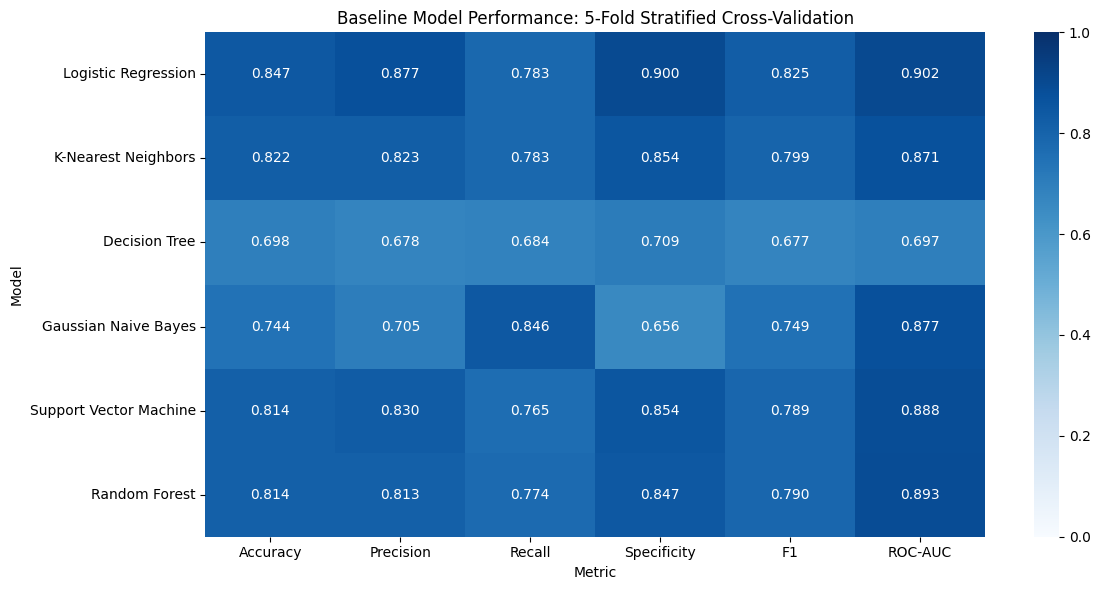

In [11]:
cv_plot_df = cv_results_df[
    [
        "Model",
        "accuracy_Mean",
        "precision_Mean",
        "recall_Mean",
        "specificity_Mean",
        "f1_Mean",
        "roc_auc_Mean"
    ]
].copy()

cv_plot_df = cv_plot_df.rename(columns={
    "accuracy_Mean": "Accuracy",
    "precision_Mean": "Precision",
    "recall_Mean": "Recall",
    "specificity_Mean": "Specificity",
    "f1_Mean": "F1",
    "roc_auc_Mean": "ROC-AUC"
}).set_index("Model")

plt.figure(figsize=(12, 6))
sns.heatmap(
    cv_plot_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1
)
plt.title("Baseline Model Performance: 5-Fold Stratified Cross-Validation")
plt.ylabel("Model")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()


## 14. Baseline Model Selection

The baseline model for final test evaluation is selected using the cross-validation results obtained from the training set.

ROC-AUC is used as the primary comparison metric because it evaluates discrimination across classification thresholds. Recall, precision, F1-score, and accuracy are also considered to provide a balanced assessment of classification performance.

The final test set is not used to select the model.


In [12]:
best_model_name = (
    cv_results_df
    .sort_values("roc_auc_Mean", ascending=False)
    .iloc[0]["Model"]
)

best_model_name


'Logistic Regression'

## 15. Fit Selected Baseline Model

In [13]:
best_pipeline = model_pipelines[best_model_name]

best_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 16. Final Test Evaluation

After baseline model selection using only the training data and cross-validation, the selected baseline model is evaluated once on the previously untouched test set.

This provides an independent estimate of performance on observations that were not used during preprocessing fitting, cross-validation, or model selection.

In [14]:
y_test_pred = best_pipeline.predict(X_test)

y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]

## 17. Final Test Metrics

In [15]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

cm = confusion_matrix(
    y_test,
    y_test_pred
)

tn, fp, fn, tp = cm.ravel()

test_specificity = tn / (tn + fp)

test_results_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall (Sensitivity)",
        "Specificity",
        "F1-score",
        "ROC-AUC"
    ],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_specificity,
        test_f1,
        test_roc_auc
    ]
})

display(
    test_results_df.round(4)
)


,Metric,Score
0,Accuracy,0.8852
1,Precision,0.8387
2,Recall (Sensitivity),0.9286
3,Specificity,0.8485
4,F1-score,0.8814
5,ROC-AUC,0.9665


## 18. Confusion Matrix

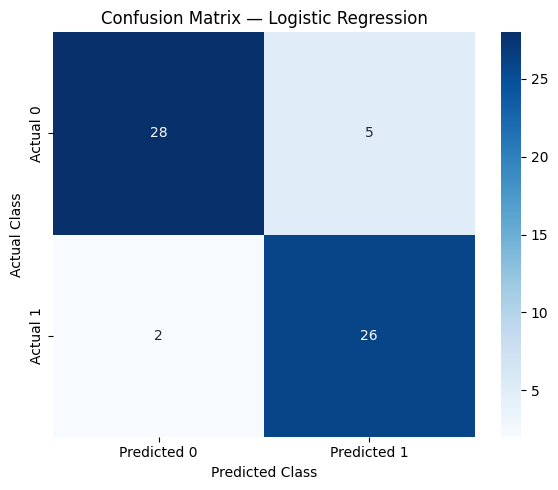

In [16]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()


## 19. Classification Report

In [17]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.93      0.85      0.89        33
   Heart Disease       0.84      0.93      0.88        28

        accuracy                           0.89        61
       macro avg       0.89      0.89      0.89        61
    weighted avg       0.89      0.89      0.89        61



## 20. ROC Curve

    Threshold  False Positive Rate  True Positive Rate
0         inf             0.000000            0.000000
1    0.989762             0.000000            0.035714
2    0.858882             0.000000            0.642857
3    0.856993             0.030303            0.642857
4    0.765908             0.030303            0.785714
5    0.727604             0.060606            0.785714
6    0.696668             0.060606            0.892857
7    0.531709             0.151515            0.892857
8    0.507870             0.151515            0.928571
9    0.487300             0.181818            0.928571
10   0.437529             0.181818            0.964286
11   0.311841             0.303030            0.964286
12   0.266731             0.303030            1.000000
13   0.013244             1.000000            1.000000


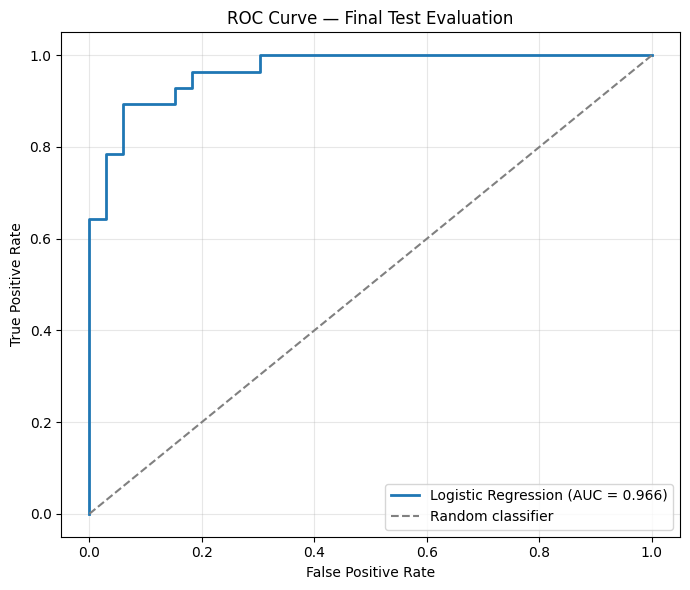

In [18]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_proba
)

roc_auc = auc(
    fpr,
    tpr
)

roc_table = pd.DataFrame({
    "Threshold": thresholds,
    "False Positive Rate": fpr,
    "True Positive Rate": tpr
})

print(roc_table)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {roc_auc:.3f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Final Test Evaluation")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 21. Compare Cross-Validation and Test Performance

In [19]:
selected_cv = cv_results_df[
    cv_results_df["Model"] == best_model_name
].iloc[0]

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall (Sensitivity)",
        "Specificity",
        "F1-score",
        "ROC-AUC"
    ],
    "Cross-Validation Mean": [
        selected_cv["accuracy_Mean"],
        selected_cv["precision_Mean"],
        selected_cv["recall_Mean"],
        selected_cv["specificity_Mean"],
        selected_cv["f1_Mean"],
        selected_cv["roc_auc_Mean"]
    ],
    "Final Test": [
        test_accuracy,
        test_precision,
        test_recall,
        test_specificity,
        test_f1,
        test_roc_auc
    ]
})

display(comparison_df.round(4))


,Metric,Cross-Validation Mean,Final Test
0,Accuracy,0.8471,0.8852
1,Precision,0.8768,0.8387
2,Recall (Sensitivity),0.7834,0.9286
3,Specificity,0.9003,0.8485
4,F1-score,0.8245,0.8814
5,ROC-AUC,0.9025,0.9665


## 22. Baseline Model Comparison

In [20]:
baseline_summary = cv_results_df[
    [
        "Model",
        "accuracy_Mean",
        "precision_Mean",
        "recall_Mean",
        "specificity_Mean",
        "f1_Mean",
        "roc_auc_Mean"
    ]
].copy()

baseline_summary = baseline_summary.sort_values(
    "roc_auc_Mean",
    ascending=False
)

display(baseline_summary.round(4))


,Model,accuracy_Mean,precision_Mean,recall_Mean,specificity_Mean,f1_Mean,roc_auc_Mean
0,Logistic Regression,0.8471,0.8768,0.7834,0.9003,0.8245,0.9025
5,Random Forest,0.8139,0.8129,0.7739,0.8470,0.7900,0.8927
4,Support Vector Machine,0.8139,0.8303,0.7648,0.8541,0.7893,0.8884
3,Gaussian Naive Bayes,0.7438,0.7049,0.8458,0.6564,0.7495,0.8773
1,K-Nearest Neighbors,0.8222,0.8232,0.7826,0.8544,0.7989,0.8712
2,Decision Tree,0.6980,0.6782,0.6842,0.7091,0.6768,0.6967


### 22.1 Verified Cross-Validation Ranking

For the current 303-record Cleveland dataset, the verified five-fold training-set results rank the models by mean ROC-AUC as follows: **Logistic Regression (0.9025), Random Forest (0.8927), Support Vector Machine (0.8884), Gaussian Naive Bayes (0.8773), K-Nearest Neighbors (0.8712), and Decision Tree (0.6967)**. These values are generated from the fixed `random_state = 42` experimental configuration and should be regenerated if the dataset or model configuration changes.


## 23. Baseline Model Findings

The baseline experiments compare six classification algorithms using the same preprocessing workflow and stratified five-fold cross-validation on the 242-observation training set.

Using ROC-AUC as the primary baseline comparison metric, Logistic Regression is the strongest baseline in the verified run (mean ROC-AUC = 0.9025), followed by Random Forest (0.8927), Support Vector Machine (0.8884), Gaussian Naive Bayes (0.8773), K-Nearest Neighbors (0.8712), and Decision Tree (0.6967). Logistic Regression also has the highest mean accuracy (0.8471) and F1-score (0.8245) among the six models.

The cross-validation results should be interpreted together with fold-to-fold variability. For Logistic Regression, the ROC-AUC standard deviation is 0.0144 across the five folds.

Model selection uses only the training-set cross-validation results. In the verified run, Logistic Regression is therefore selected for final test evaluation. On the untouched 61-observation test set, it achieved accuracy = 0.8852, precision = 0.8387, recall/sensitivity = 0.9286, specificity = 0.8485, F1-score = 0.8814, and ROC-AUC = 0.9665. The confusion matrix contains 28 true negatives, 5 false positives, 2 false negatives, and 26 true positives.

The higher test ROC-AUC and recall relative to the cross-validation means should not be interpreted as proof of superior generalization. The test set contains only 61 observations, so these estimates are subject to sampling variability. The test set remains a single final evaluation set and is not used for model selection.


## 24. Reproducibility Check

The following checks confirm the key experimental conditions used in this notebook. The numerical results above are reproducible when the same dataset, preprocessing definition, model settings, and random state are used.


In [21]:
assert X.shape == (303, 13)
assert X_train.shape == (242, 13)
assert X_test.shape == (61, 13)
assert y_train.value_counts().sort_index().to_dict() == {0: 131, 1: 111}
assert y_test.value_counts().sort_index().to_dict() == {0: 33, 1: 28}
assert best_model_name == "Logistic Regression"

print("Reproducibility checks: PASSED")
print("Selected baseline:", best_model_name)


Reproducibility checks: PASSED
Selected baseline: Logistic Regression


## 25. Limitations

The baseline experiments provide a controlled reference for comparing six machine learning classifiers, but the findings should be interpreted within the scope of the dataset and experimental design used in this notebook.

1. **Dataset size and sampling variability:** The Cleveland subset contains 303 observations, with 242 observations used for training and cross-validation and 61 observations reserved for final testing. The relatively small test set means that the reported test metrics can be affected by sampling variability and should not be treated as precise estimates of performance on unseen populations.

2. **Dataset scope and generalizability:** The experiments use the UCI Cleveland subset only. Therefore, the results describe performance on this dataset and do not establish that the same performance would be obtained on patients from other populations, institutions, or datasets.

3. **Single final train/test split:** The final evaluation uses one stratified 80:20 train/test split with `random_state=42`. Although five-fold stratified cross-validation is used within the training data for model comparison, the final test estimate is based on one held-out split rather than repeated splits or an independent external validation dataset.

4. **Baseline-stage model scope:** This notebook is intended to establish baseline performance. It does not include systematic hyperparameter tuning, feature-selection experiments, or advanced/ensemble modelling beyond the baseline algorithms evaluated here. Consequently, the selected Logistic Regression model should be regarded as the strongest baseline under the specified setup, not as a final optimized model.

5. **Preprocessing and feature representation:** Missing predictor values are handled through training-data-fitted imputation, and categorical variables are one-hot encoded while numerical variables are standardized. These choices provide a consistent modelling pipeline, but alternative preprocessing or feature-representation strategies could produce different results and have not been compared in this baseline stage.

6. **No external clinical validation:** The evaluation is computational and dataset-based. The results do not establish clinical validity, clinical utility, or suitability for deployment in healthcare practice. Such claims would require additional validation and evidence beyond the experiments reported here.

7. **Interpretation of performance differences:** Logistic Regression has the highest mean ROC-AUC in the verified cross-validation comparison, but differences between models should not be interpreted as universal superiority. The comparison is specific to the dataset, preprocessing pipeline, model settings, cross-validation procedure, and random state used in this notebook.


## 26. Conclusions

This notebook established a reproducible baseline for heart disease classification using the UCI Cleveland dataset. Six classification algorithms—Logistic Regression, K-Nearest Neighbors, Decision Tree, Gaussian Naive Bayes, Support Vector Machine, and Random Forest—were evaluated using the same preprocessing pipeline and stratified five-fold cross-validation on the training data.

Based on mean ROC-AUC, Logistic Regression was the strongest baseline in the verified experiment, achieving a mean ROC-AUC of 0.9025, followed by Random Forest (0.8927), Support Vector Machine (0.8884), Gaussian Naive Bayes (0.8773), K-Nearest Neighbors (0.8712), and Decision Tree (0.6967). Logistic Regression was therefore selected for evaluation on the untouched test set.

On the 61-observation test set, the selected Logistic Regression model achieved an accuracy of 0.8852, precision of 0.8387, recall/sensitivity of 0.9286, specificity of 0.8485, F1-score of 0.8814, and ROC-AUC of 0.9665. The corresponding confusion matrix contained 28 true negatives, 5 false positives, 2 false negatives, and 26 true positives.

These results establish Logistic Regression as the reference baseline for the subsequent stages of the project. They do not, by themselves, demonstrate clinical applicability or superior generalization beyond the Cleveland dataset. The relatively small held-out test set also means that the final test metrics should be interpreted with appropriate caution.

The baseline findings provide a controlled point of comparison for subsequent experiments, including any feature-selection or advanced/ensemble modelling undertaken later. Future comparisons should retain the same evaluation discipline and should report only results that are obtained from the corresponding experiments.